# Manual Pipeline 2
- In this notebook, I will refactor the manual_pipeline1 processing into a single function.
- I will have an option for autopower or n_points as part of the function.
- Add function that tests for closeness between selected peaks:
    - Consider the LSP resolution.
- Afterwards cluster peaks in the same ranges and choose the strongest like in the priors analysis.

In [11]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


# Individual stars
raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_sol = pd.read_csv(r"../../Data/misc/sol_sind_all.txt", sep='\s',skip_blank_lines=True)

def prepare_df(data, add_prefix=False):
    data = data.copy()
    data.columns = ["JD", "sind"]
    if add_prefix:
        data['JD'] = data['JD'] + 2400000.0
    time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
    data["year"] = time_obj.jyear
    data["day"] = time_obj.jd
    data['datetime'] = time_obj.to_datetime(timezone=None)
    data = data.set_index('datetime')
    return data


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()


data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)
data_sol = prepare_df(raw_sol, add_prefix=True)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)
train_sol, valid_sol, test_sol = split_df(data_sol)


C:\Users\Joey\AppData\Local\Temp\ipykernel_23484\3086042020.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_23484\3086042020.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_23484\3086042020.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support rege

In [29]:
def check_aliases(freq, accepted_freqs, tol = 0.05):
    '''
    Check if a single period is an alias.
    If it is an alias we can skip it and use the next period as dominant.
    Aliases are not subtracted: they are noise.
    If True, signal is not an alias so set it be added.
    '''
    accepted_periods = 1/np.array(accepted_freqs)
    for p in accepted_periods:
        for mult in [0.25, 1/3, 0.5, 1, 2, 3, 4]:
            pmult_freq = 1/(p*mult)
            delta = np.abs((freq - pmult_freq)/freq)
            if delta < tol: # The signal is an alias
                return False, p, mult, delta
    return True, None, None, None

def check_windows(freq, tol = 0.05):
    '''
    Checks if a signal looks suspiciously like a window function.
    If True, signal is not a window as defined.
    '''
    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week, 29.5] #29.5 is lunar
    for window in windows:
        window_freq = 1/np.array(window)
        delta = np.abs((freq-window_freq)/freq)
        if delta < tol: # Then we classify the signal as a window function
            return False, window, delta
    return True, None, None

# Helpers for performing the SNR checks
def gaussian(t, A, mu, std, c):
    return A * np.exp(-0.5 * ((t - mu) / std)**2) + c

def find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150):
    '''
    Fits a Gaussian around a peak, subtracts that peak Gaussian, and then compares it to the remaining residual noise.
    '''
    # Define a window around the peak to which to fit a Gaussian
    n = len(powers)
    left  = max(0, peak_idx - window)
    right = min(n, peak_idx + window + 1)
    window_freqs = freqs[left:right]
    window_powers = powers[left:right]
    minf = min(window_freqs)
    maxf = max(window_freqs)

    # Define initial guesses for the fit
    A0 = peak_height
    mu0 = peak_freq
    std0 = mu0 * 0.1 #FWHM is a bit overkill
    c0 = np.median(window_powers)
    p0 = [A0, mu0, std0, c0]

    # Try the curve fit
    try:
        popt, _ = curve_fit(gaussian, window_freqs, window_powers,
                        p0 = p0,
                        bounds = ([0, minf, 0, 0], [np.inf, maxf, np.inf, np.inf]))
        resid_lsp = window_powers - gaussian(window_freqs, *popt)
        noise_std = np.std(resid_lsp)
        snr = A0 / noise_std
        return snr, popt, resid_lsp
    except (RuntimeError, ValueError):
        continuum = np.median(window_powers)
        noise = np.std(window_powers)
        return (A0 - continuum) / noise, None, None


def build_design_matrix(t, accepted_freqs):
    cols = [np.ones(len(t))]
    for f in accepted_freqs:
        cols.append(np.cos(2 * np.pi * f * t))
        cols.append(np.sin(2 * np.pi * f * t))
    return np.column_stack(cols)

def simultaneous_fit(t, y, accepted_freqs):
    if not accepted_freqs:
        return y, np.array([np.mean(y)])
    X = build_design_matrix(t, accepted_freqs)
    params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted_model = X @ params
    residuals = y - fitted_model
    return residuals, params

def set_period_axes(ax, ylabel='Normalised Power'):
    ax.set_xlabel('Period (days)', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

In [32]:
def fit_peaks(df,
            manual_freq = 'log', period_range = [0.1, 100*365], n_periods = 100000, 
            FAPs = [0.1], key_FAP_idx = -1, 
            threshold = 5,
            plot = True, verbose = True,
            savefig = None):
    '''
    Iteratively finds the peaks of the LSP.
    This will be used in the prior selsection process.
    Finds one peak then checks if it is an alias or a window.
    Also checks if it is too similar to a previous peak for the LSP to have resolved.
    If that peak also satiesfies an SNR threshold, add it to an accepted periods list.

    df is the dataframe being processed (training set)
    manual_freq True means the period_range and n_periods defines the set of periods calculated.
    Period_range is in days

    Returns a list of accepted periods.
    '''
    accepted_peak_freqs = []
    accepted_peak_heights = []

    if manual_freq == 'linear':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.linspace(min_period, max_period, n_periods)
        freqs = 1 / periods
    if manual_freq == 'log':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.logspace(np.log10(min_period), np.log10(max_period), n_periods)
        freqs = 1 / periods

    resids = [df['sind']]
    iter_powers = []
    iter_params = []
    iter_peak_freqs = []
    iter_invFAPs = []
    iter_popts = []
    iter_SNRs = []

    i = 0
    t = df['day']
    data_timeframe = t[-1] - t[0]
    max_detectable_period = 3 * data_timeframe
    print(max_detectable_period)

    FAPs = np.array(FAPs)/100

    while True:
        ls = LombScargle(t, resids[i])
        if manual_freq is None:
            freqs, powers = ls.autopower()
            periods = 1/freqs
        else:
            powers = ls.power(freqs)

        power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
        key_FAP = float(power_invFAPs[key_FAP_idx])
        peak_idxs, properties = find_peaks(powers, height=key_FAP)
        peak_freqs = freqs[peak_idxs]
        peak_heights = properties['peak_heights']

        if len(peak_freqs) == 0:
            break

        sort_idx = np.argsort(peak_heights)[::-1]
        peak_freqs = peak_freqs[sort_idx]
        peak_heights = peak_heights[sort_idx] 
        peak_idxs = peak_idxs[sort_idx]

        found = False
        for peak_freq, peak_height, peak_idx in zip(peak_freqs, peak_heights, peak_idxs):

            if 1/peak_freq > max_detectable_period:
                print(f"Peak at period {1/peak_freq:.2f} days is greater than maximum detectable period of {max_detectable_period} days.")
            else:
                alias_cond, p, mult, delta = check_aliases(freq = peak_freq, accepted_freqs= accepted_peak_freqs)
                if alias_cond == False:
                    print(f"Peak at period {1/peak_freq:.2f} was identified to be an alias of {p:.2f} days at mult {mult:.2f} by tolerance {delta:.2f}.")
                else:
                    window_cond, window, delta = check_windows(freq = peak_freq)
                    if window_cond == False:
                        print(f"Peak at period {1/peak_freq:.2f} was identified to be a window of {window:.2f} days by tolerance {delta:.2f}.")
                    else:
                        snr, popt, resid_lsr = find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150)
                        if popt is None:
                            print("SNR failed to fit Gaussian. Fell back to height vs average.")

                        if snr > threshold:
                            accepted_peak_freqs.append(peak_freq)
                            accepted_peak_heights.append(peak_height)
                            found = True
                            print(f"In iteration {i}, period at {1/peak_freq:.2f} days was accepted.")
                            break
                        else:
                            print(f"Period of {1/peak_freq:.2f} failed SNR > {threshold} with SNR of {snr}")

        if found == False:
            print(f"Iteration {i} did not find a frequency: terminating loop.")
            break
        else:
            resid, params = simultaneous_fit(df['day'], df['sind'], accepted_peak_freqs)
            resids.append(resid)
            iter_powers.append(powers)
            iter_params.append(params)
            iter_peak_freqs.append(peak_freqs)
            iter_invFAPs.append(power_invFAPs)
            iter_SNRs.append(snr)
            iter_popts.append(popt if popt is not None else None)
            i += 1

    periods = 1/freqs

    n_iter = len(resids) - 1
    n_plot = min(n_iter, 5)

    if plot and n_plot > 0:
        fig, ax = plt.subplots(n_plot, 2, figsize=(8.27, 11.69), dpi=200)
        ax = np.atleast_2d(ax)

        col_titles = ['LSP', 'Fit & Residuals']
        for col, title in enumerate(col_titles):
            ax[0][col].set_title(title, fontsize=10, fontweight='bold')

        fap_colors = ['#e74c3c']

        for row in range(n_plot):
            # ---- Col 0: LSP ----
            ax[row][0].set_xscale('log')
            ax[row][0].plot(periods, iter_powers[row], label='LS Periodogram')
            set_period_axes(ax[row][0])

            power_invFAPs = iter_invFAPs[row]
            for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
                ax[row][0].axhline(power_invFAP, color=fap_color, label=f'FAP {fap_level * 100:.1f}%', lw=0.4)

            peak_periods_row = 1 / np.array(iter_peak_freqs[row])
            for j, peak_period in enumerate(peak_periods_row):
                ax[row][0].axvline(peak_period, color='purple', lw=0.4, label='Peak' if j == 0 else None)

            popt = iter_popts[row]
            if popt is not None:
                ax[row][0].plot(periods, gaussian(freqs, *popt), color='lime', label='Gaussian fit')

            if row == 0:
                ax[row][0].legend(fontsize=7, framealpha=0.9)

            # ---- Col 1: Fit & Residuals ----
            ax_t = ax[row][1]
            prev_resid = np.array(resids[row])
            curr_resid = np.array(resids[row + 1])
            fit_component = prev_resid - curr_resid

            t_vals = np.array(t)
            sort_idx = np.argsort(t_vals)

            ax_t.scatter(t_vals, prev_resid, s=2, color='orange', alpha=0.1, marker='x',label='Previous residual', zorder=1)
            ax_t.scatter(t_vals, curr_resid, s=2, color='green',  alpha=0.1, marker='x',label='Residual',          zorder=2)
            ax_t.plot(t_vals[sort_idx], fit_component[sort_idx], color='blue', lw=1, label='Simultaneous fit', zorder=3)
            ax_t.set_xlabel('Time (days)', fontsize=8)
            ax_t.set_ylabel('S-index', fontsize=8)
            ax_t.tick_params(axis='both', labelsize=7)

            if row == 0:
                ax_t.legend(fontsize=7, framealpha=0.9, markerscale=3)

        plt.tight_layout()
        if savefig:
            fig.savefig(savefig)
        plt.show()

    accepted_peak_periods = 1/np.array(accepted_peak_freqs)
    if verbose:
        print("Accepted periods and their heights")
        table = PrettyTable(["Days", "Years", "Height", "SNR"])
        for accepted_peak_period, accepted_peak_height, snr in zip(accepted_peak_periods, accepted_peak_heights, iter_SNRs):
            table.add_row([f"{accepted_peak_period:.2f}", f"{accepted_peak_period/365:.2f}", f"{accepted_peak_height:.2f}", f"{snr:.2f}"])
        print(table)

    return accepted_peak_periods, accepted_peak_heights


---
## Verification
- Now that we have some code to do the analysis that is verified against the first star, now we can run it for all three and compare to the literature values.

Solar

C:\Users\Joey\AppData\Local\Temp\ipykernel_23484\2031943341.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


46444.935000000056
In iteration 0, period at 3819.63 days was accepted.
Peak at period 1947.09 was identified to be an alias of 3819.63 days at mult 0.50 by tolerance 0.02.
Peak at period 14965.11 was identified to be an alias of 3819.63 days at mult 4.00 by tolerance 0.02.
Period of 2896.35 failed SNR > 5 with SNR of 1.9785091915869855
Peak at period 1298.92 was identified to be an alias of 3819.63 days at mult 0.33 by tolerance 0.02.
Period of 833.85 failed SNR > 5 with SNR of 4.0811158149665
Peak at period 950.24 was identified to be an alias of 3819.63 days at mult 0.25 by tolerance 0.00.
Period of 655.38 failed SNR > 5 with SNR of 3.3642284706530363
Period of 540.81 failed SNR > 5 with SNR of 3.9829474422412936
In iteration 1, period at 0.33 days was accepted.
In iteration 2, period at 13893.51 days was accepted.
In iteration 3, period at 2007.88 days was accepted.
In iteration 4, period at 2881.55 days was accepted.
Period of 827.47 failed SNR > 5 with SNR of 4.734180048582768
Pe

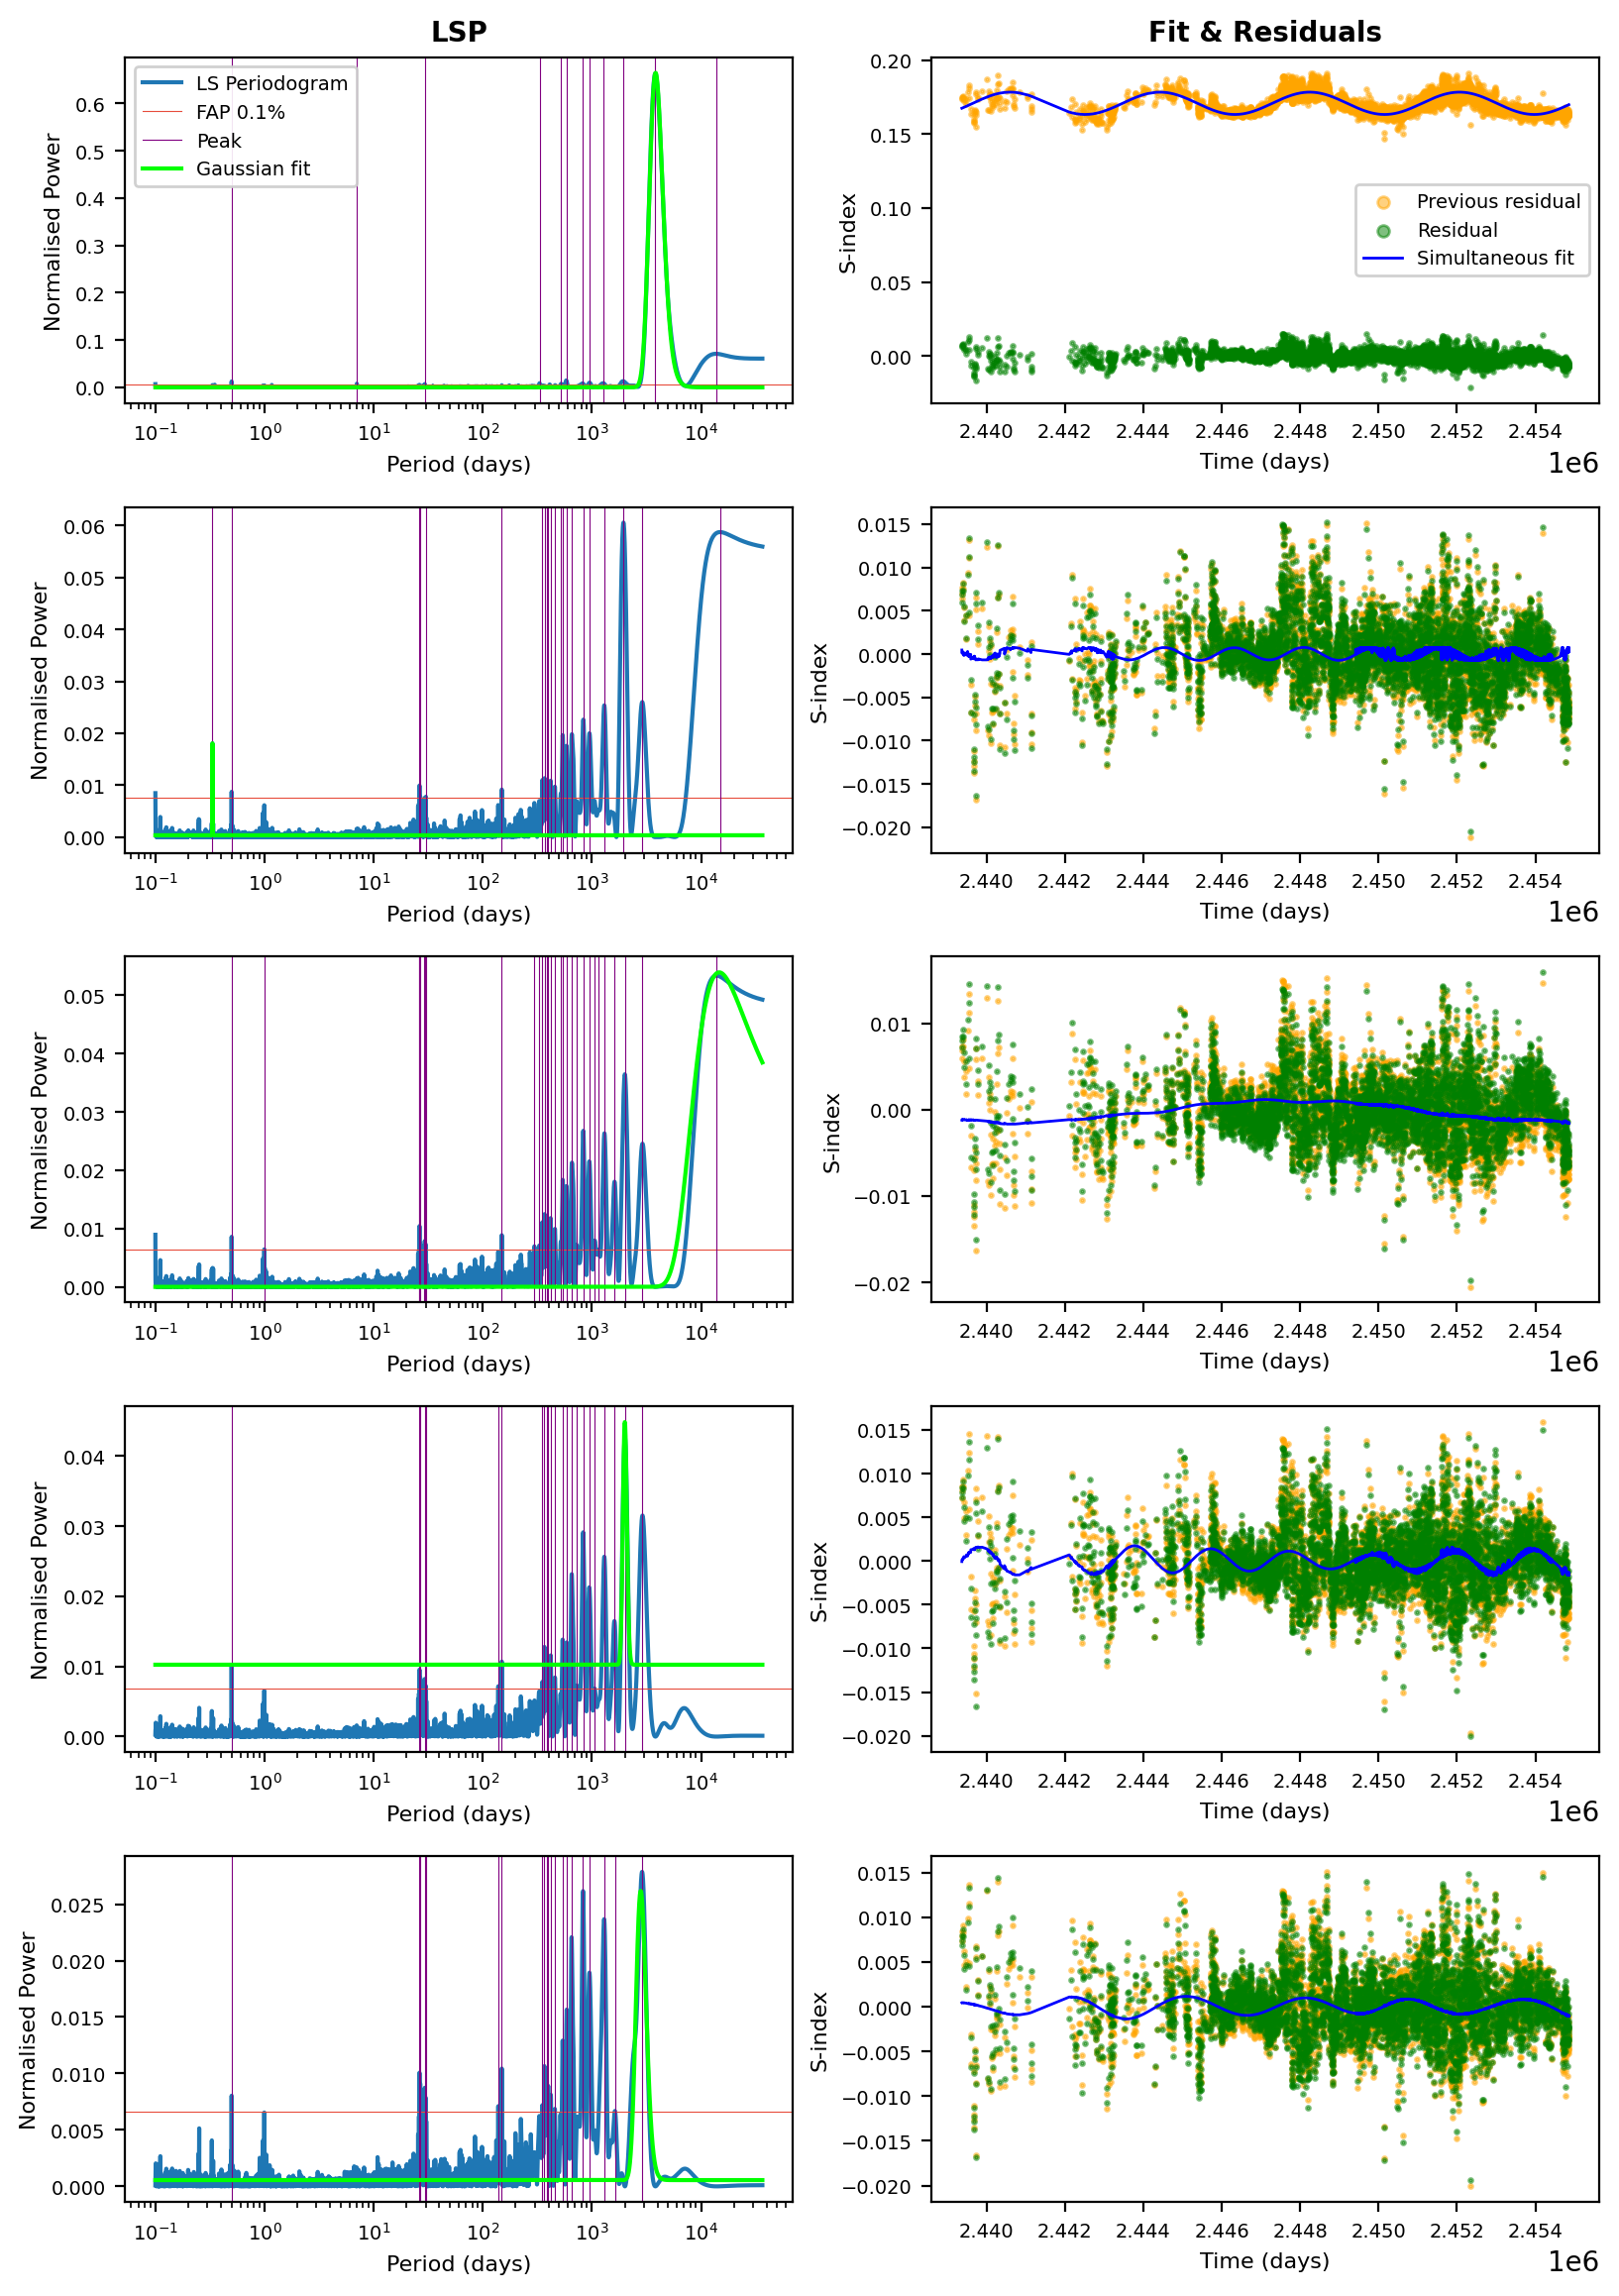

Accepted periods and their heights
+----------+-------+--------+-------+
|   Days   | Years | Height |  SNR  |
+----------+-------+--------+-------+
| 3819.63  | 10.46 |  0.66  | 84.06 |
|   0.33   |  0.00 |  0.02  | 37.07 |
| 13893.51 | 38.06 |  0.05  | 75.37 |
| 2007.88  |  5.50 |  0.04  |  5.38 |
| 2881.55  |  7.89 |  0.03  | 11.04 |
|  149.44  |  0.41 |  0.01  |  7.57 |
|   0.50   |  0.00 |  0.01  | 26.06 |
|  26.31   |  0.07 |  0.01  |  6.82 |
|  138.39  |  0.38 |  0.01  |  7.28 |
|  827.47  |  2.27 |  0.03  |  5.03 |
+----------+-------+--------+-------+


In [31]:
peaks_sol, heights_sol = fit_peaks(train_sol, n_periods = 5000, savefig=r"../../Report/Figures/SolarLSPLoop.png")

HD81809

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\3629258397.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


28511.88663000008
In iteration 0, period at 2991.66 days was accepted.
In iteration 1, period at 40.25 days was accepted.
In iteration 2, period at 44.27 days was accepted.
In iteration 3, period at 1813.07 days was accepted.
Peak at period 41.71 was identified to be an alias of 40.25 days at mult 1.00 by tolerance 0.04.
Peak at period 7119.84 was identified to be an alias of 1813.07 days at mult 4.00 by tolerance 0.02.
In iteration 4, period at 37.33 days was accepted.
In iteration 5, period at 6847.55 days was accepted.
Peak at period 42.44 was identified to be an alias of 44.27 days at mult 1.00 by tolerance 0.04.
Peak at period 21.27 was identified to be an alias of 44.27 days at mult 0.50 by tolerance 0.04.
Peak at period 38.06 was identified to be an alias of 37.33 days at mult 1.00 by tolerance 0.02.
Period of 47.19 failed SNR > 5 with SNR of 4.633401992630882
Iteration 6 did not find a frequency: terminating loop.


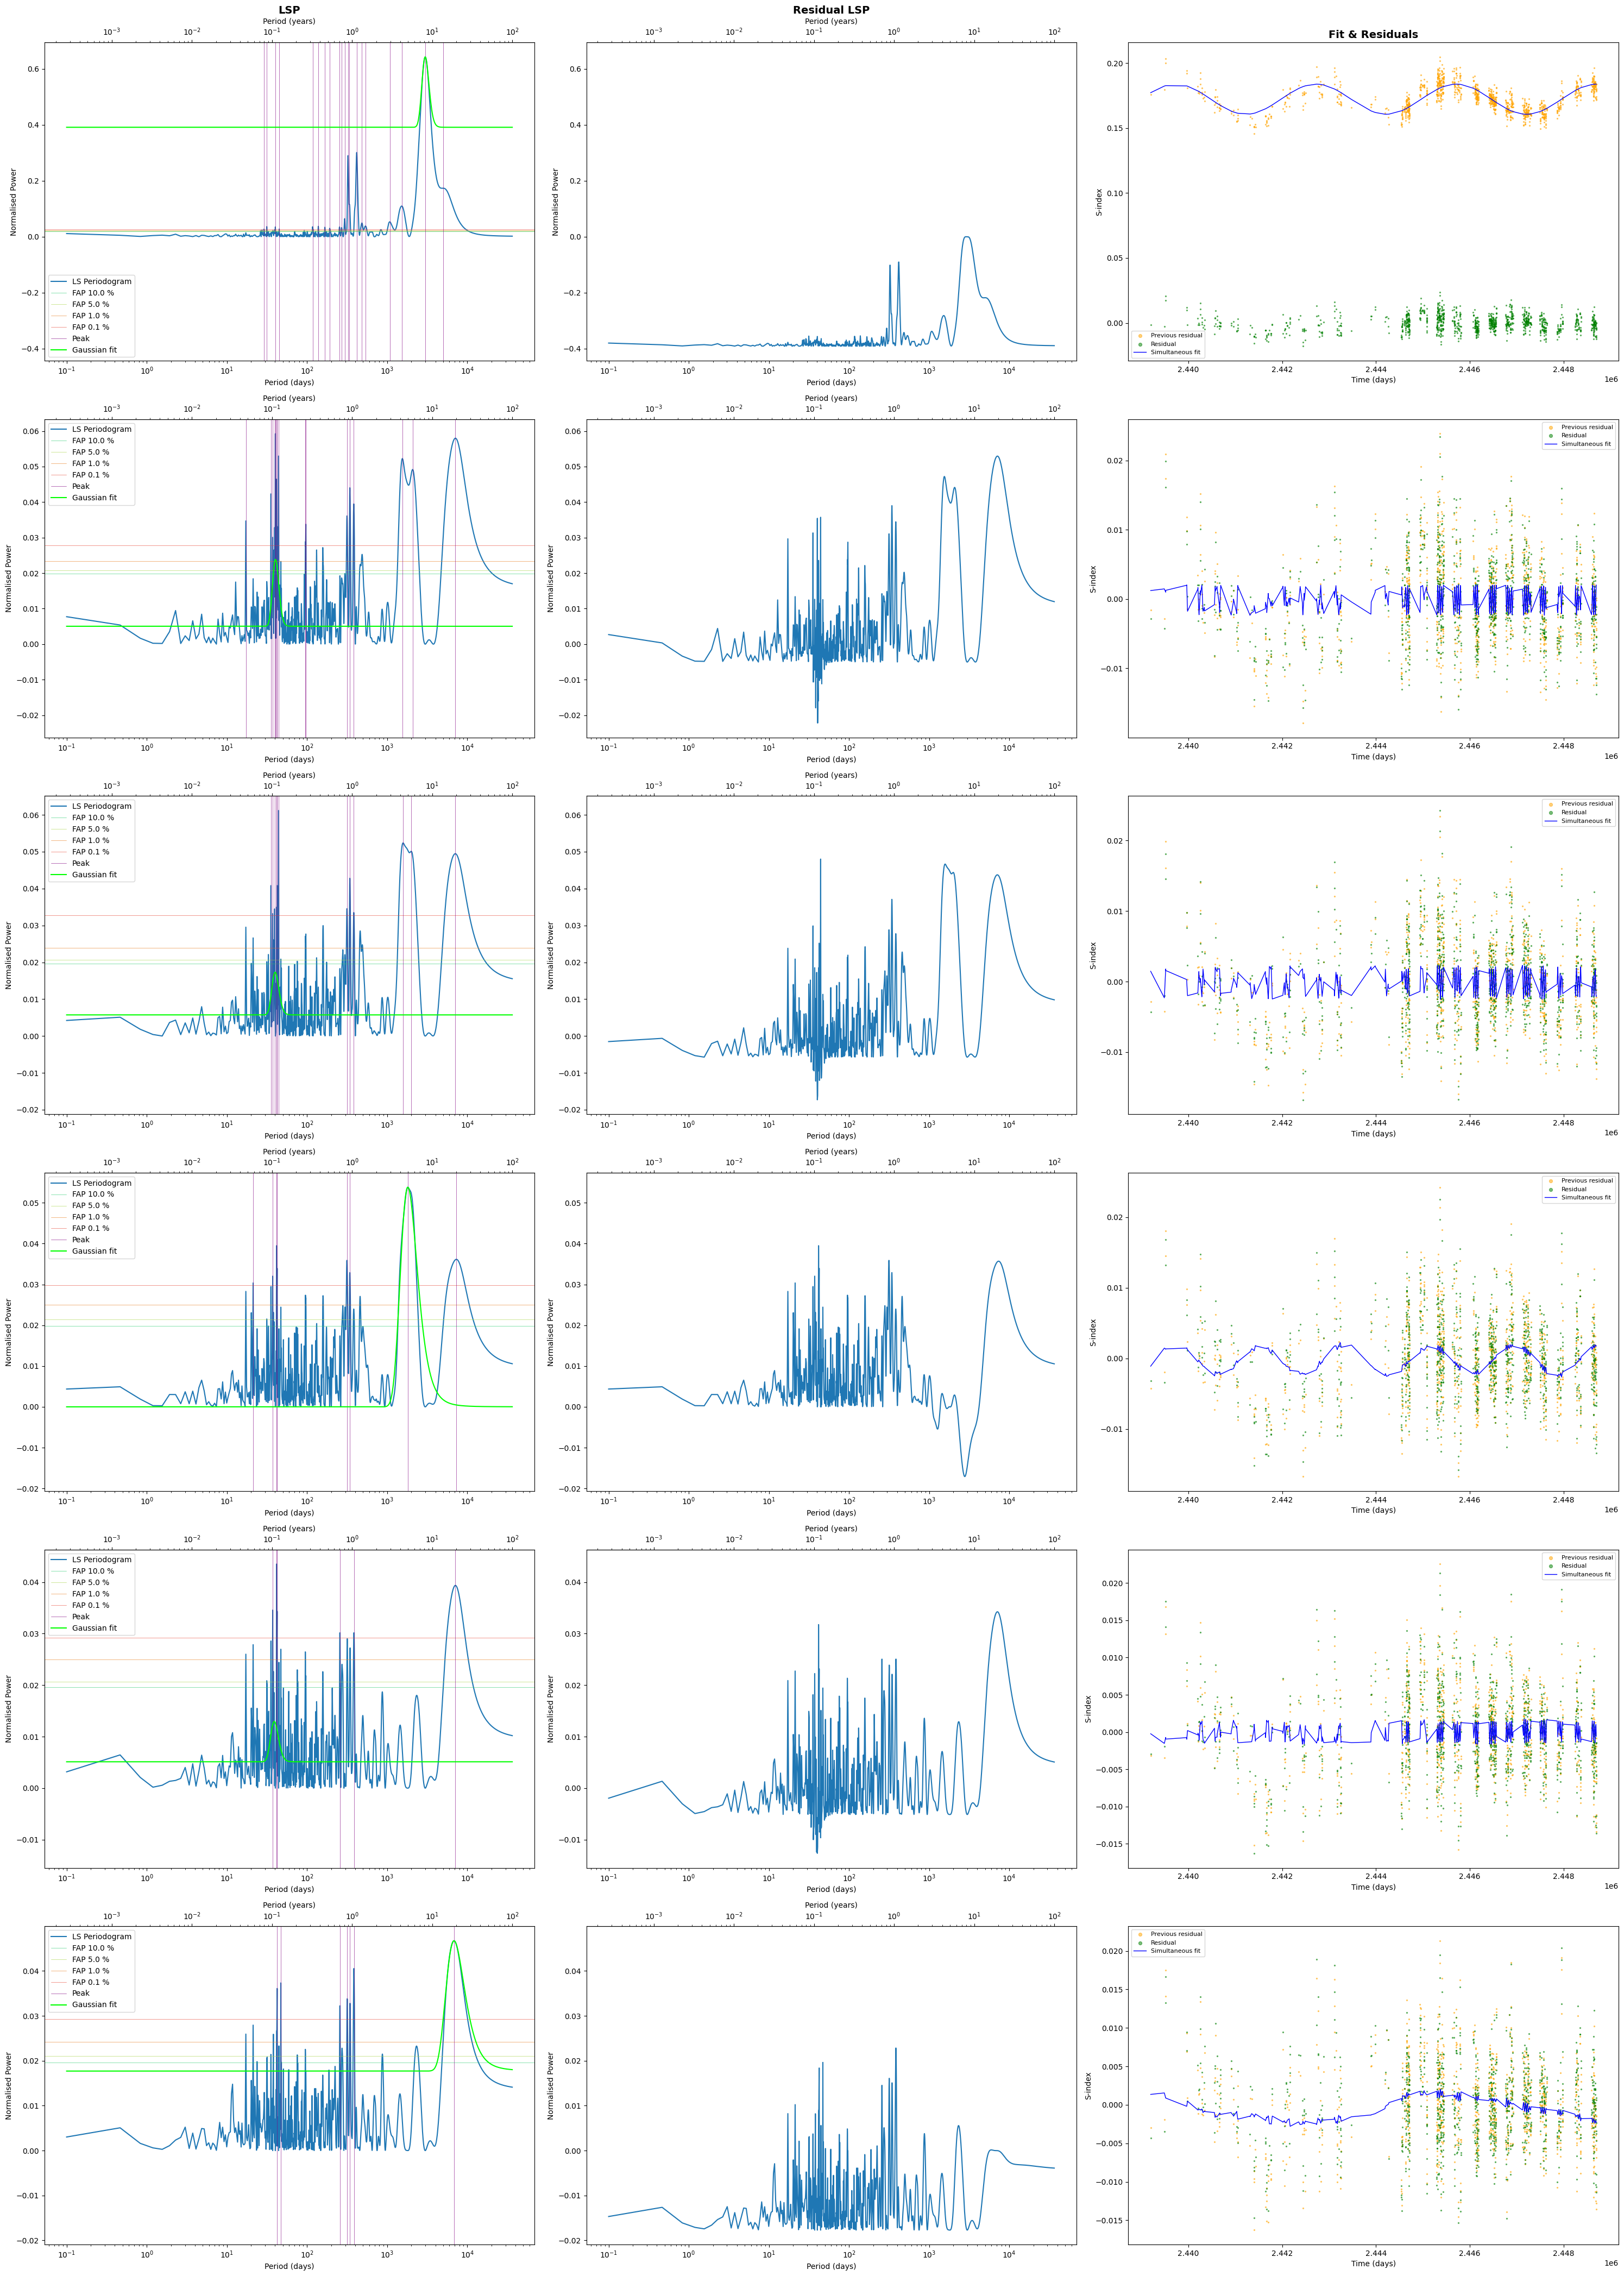

Accepted periods and their heights
+---------+-------+--------+------------+
|   Days  | Years | Height |    SNR     |
+---------+-------+--------+------------+
| 2991.66 |  8.20 |  0.64  |  76181.21  |
|  40.25  |  0.11 |  0.06  |    8.76    |
|  44.27  |  0.12 |  0.06  |    8.00    |
| 1813.07 |  4.97 |  0.05  |  3539.12   |
|  37.33  |  0.10 |  0.03  |    5.32    |
| 6847.55 | 18.76 |  0.05  | 3575428.99 |
+---------+-------+--------+------------+


In [ ]:
peaks_HD81809, heights_HD81809 = fit_peaks(train_HD81809)

HD160346

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\3629258397.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


25379.70644999994
In iteration 0, period at 2505.48 days was accepted.
In iteration 1, period at 23064.62 days was accepted.
In iteration 2, period at 468.40 days was accepted.
Peak at period 1341.12 was identified to be an alias of 468.40 days at mult 3.00 by tolerance 0.05.
In iteration 3, period at 1082.70 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
In iteration 4, period at 35.14 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
Peak at period 107.78 was identified to be an alias of 35.14 days at mult 3.00 by tolerance 0.02.
Period of 405.62 failed SNR > 5 with SNR of 4.931436498095705
In iteration 5, period at 96.10 days was accepted.
In iteration 6, period at 404.89 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
Peak at period 107.78 was identified to be an alias of 35.1

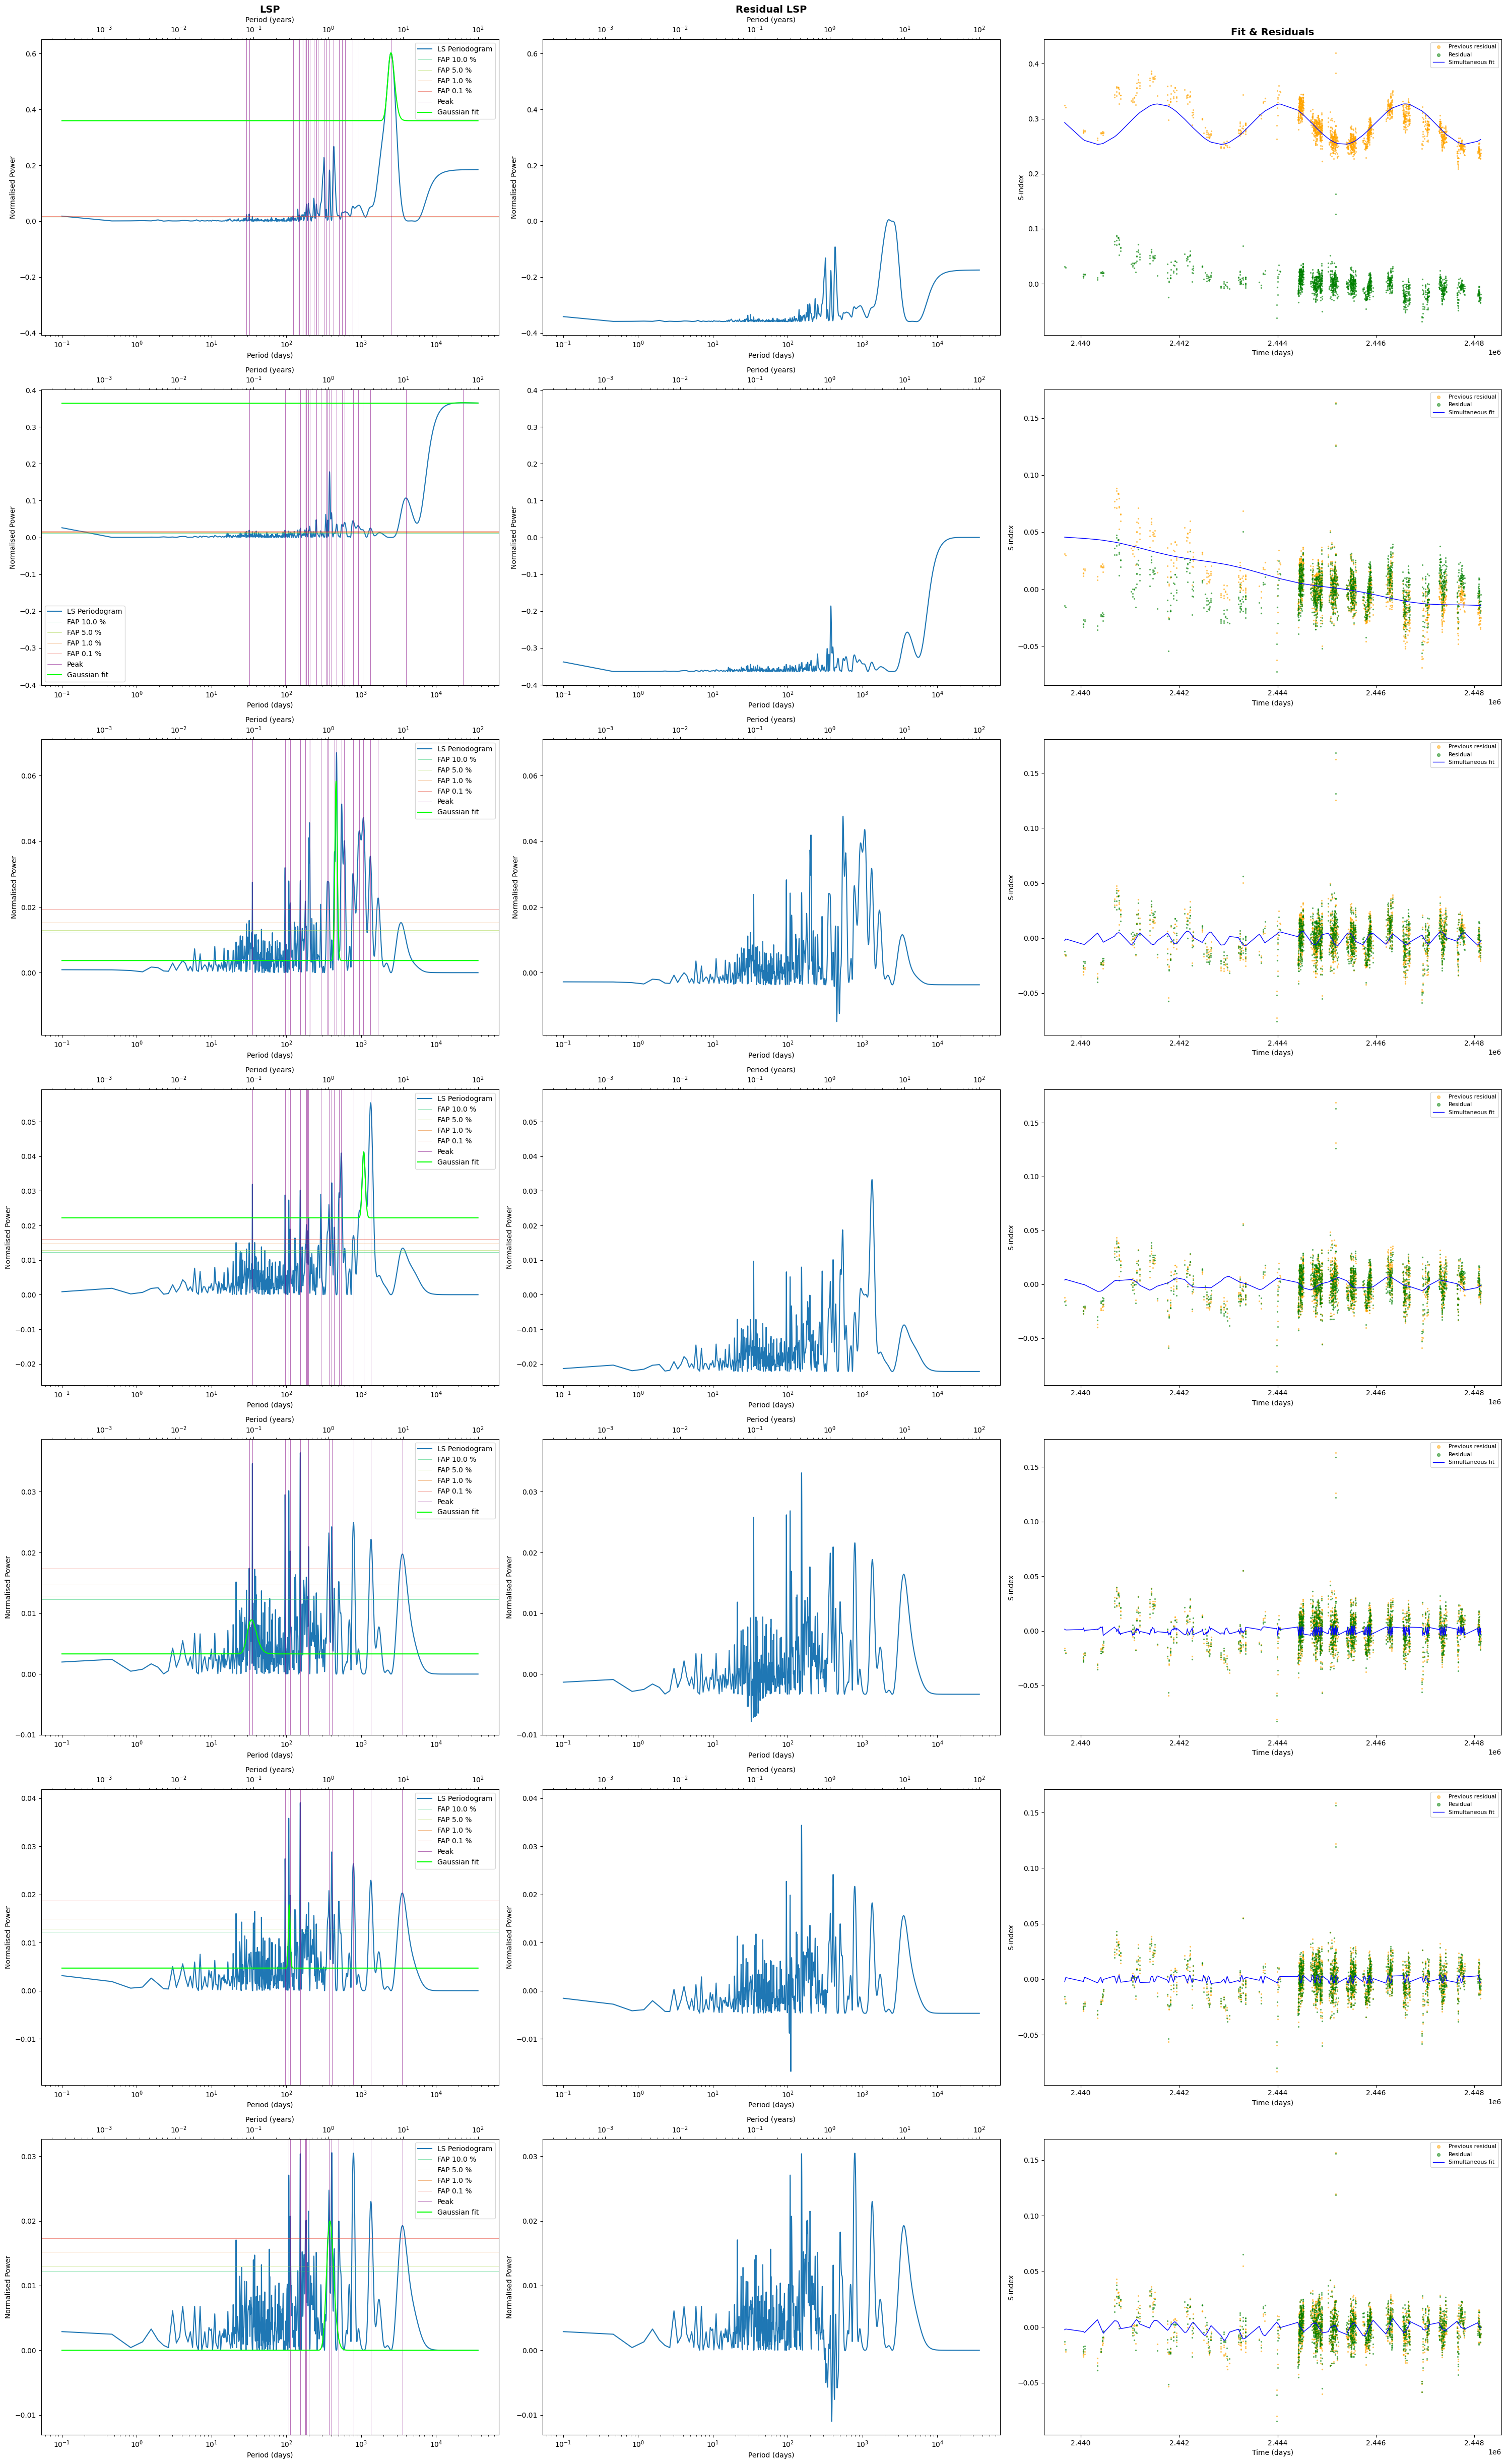

Accepted periods and their heights
+----------+-------+--------+----------------+
|   Days   | Years | Height |      SNR       |
+----------+-------+--------+----------------+
| 2505.48  |  6.86 |  0.60  |    20391.25    |
| 23064.62 | 63.19 |  0.37  | 21331058221.45 |
|  468.40  |  1.28 |  0.07  |      7.99      |
| 1082.70  |  2.97 |  0.04  |     454.11     |
|  35.14   |  0.10 |  0.03  |      9.69      |
|  96.10   |  0.26 |  0.03  |      5.61      |
|  404.89  |  1.11 |  0.03  |      5.18      |
+----------+-------+--------+----------------+


In [ ]:
peaks_HD160346, heights_HD160346 = fit_peaks(train_HD160346)

HD201091 

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\3629258397.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


24515.431799999904
In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 was identified to be an alias of 505.26 days a

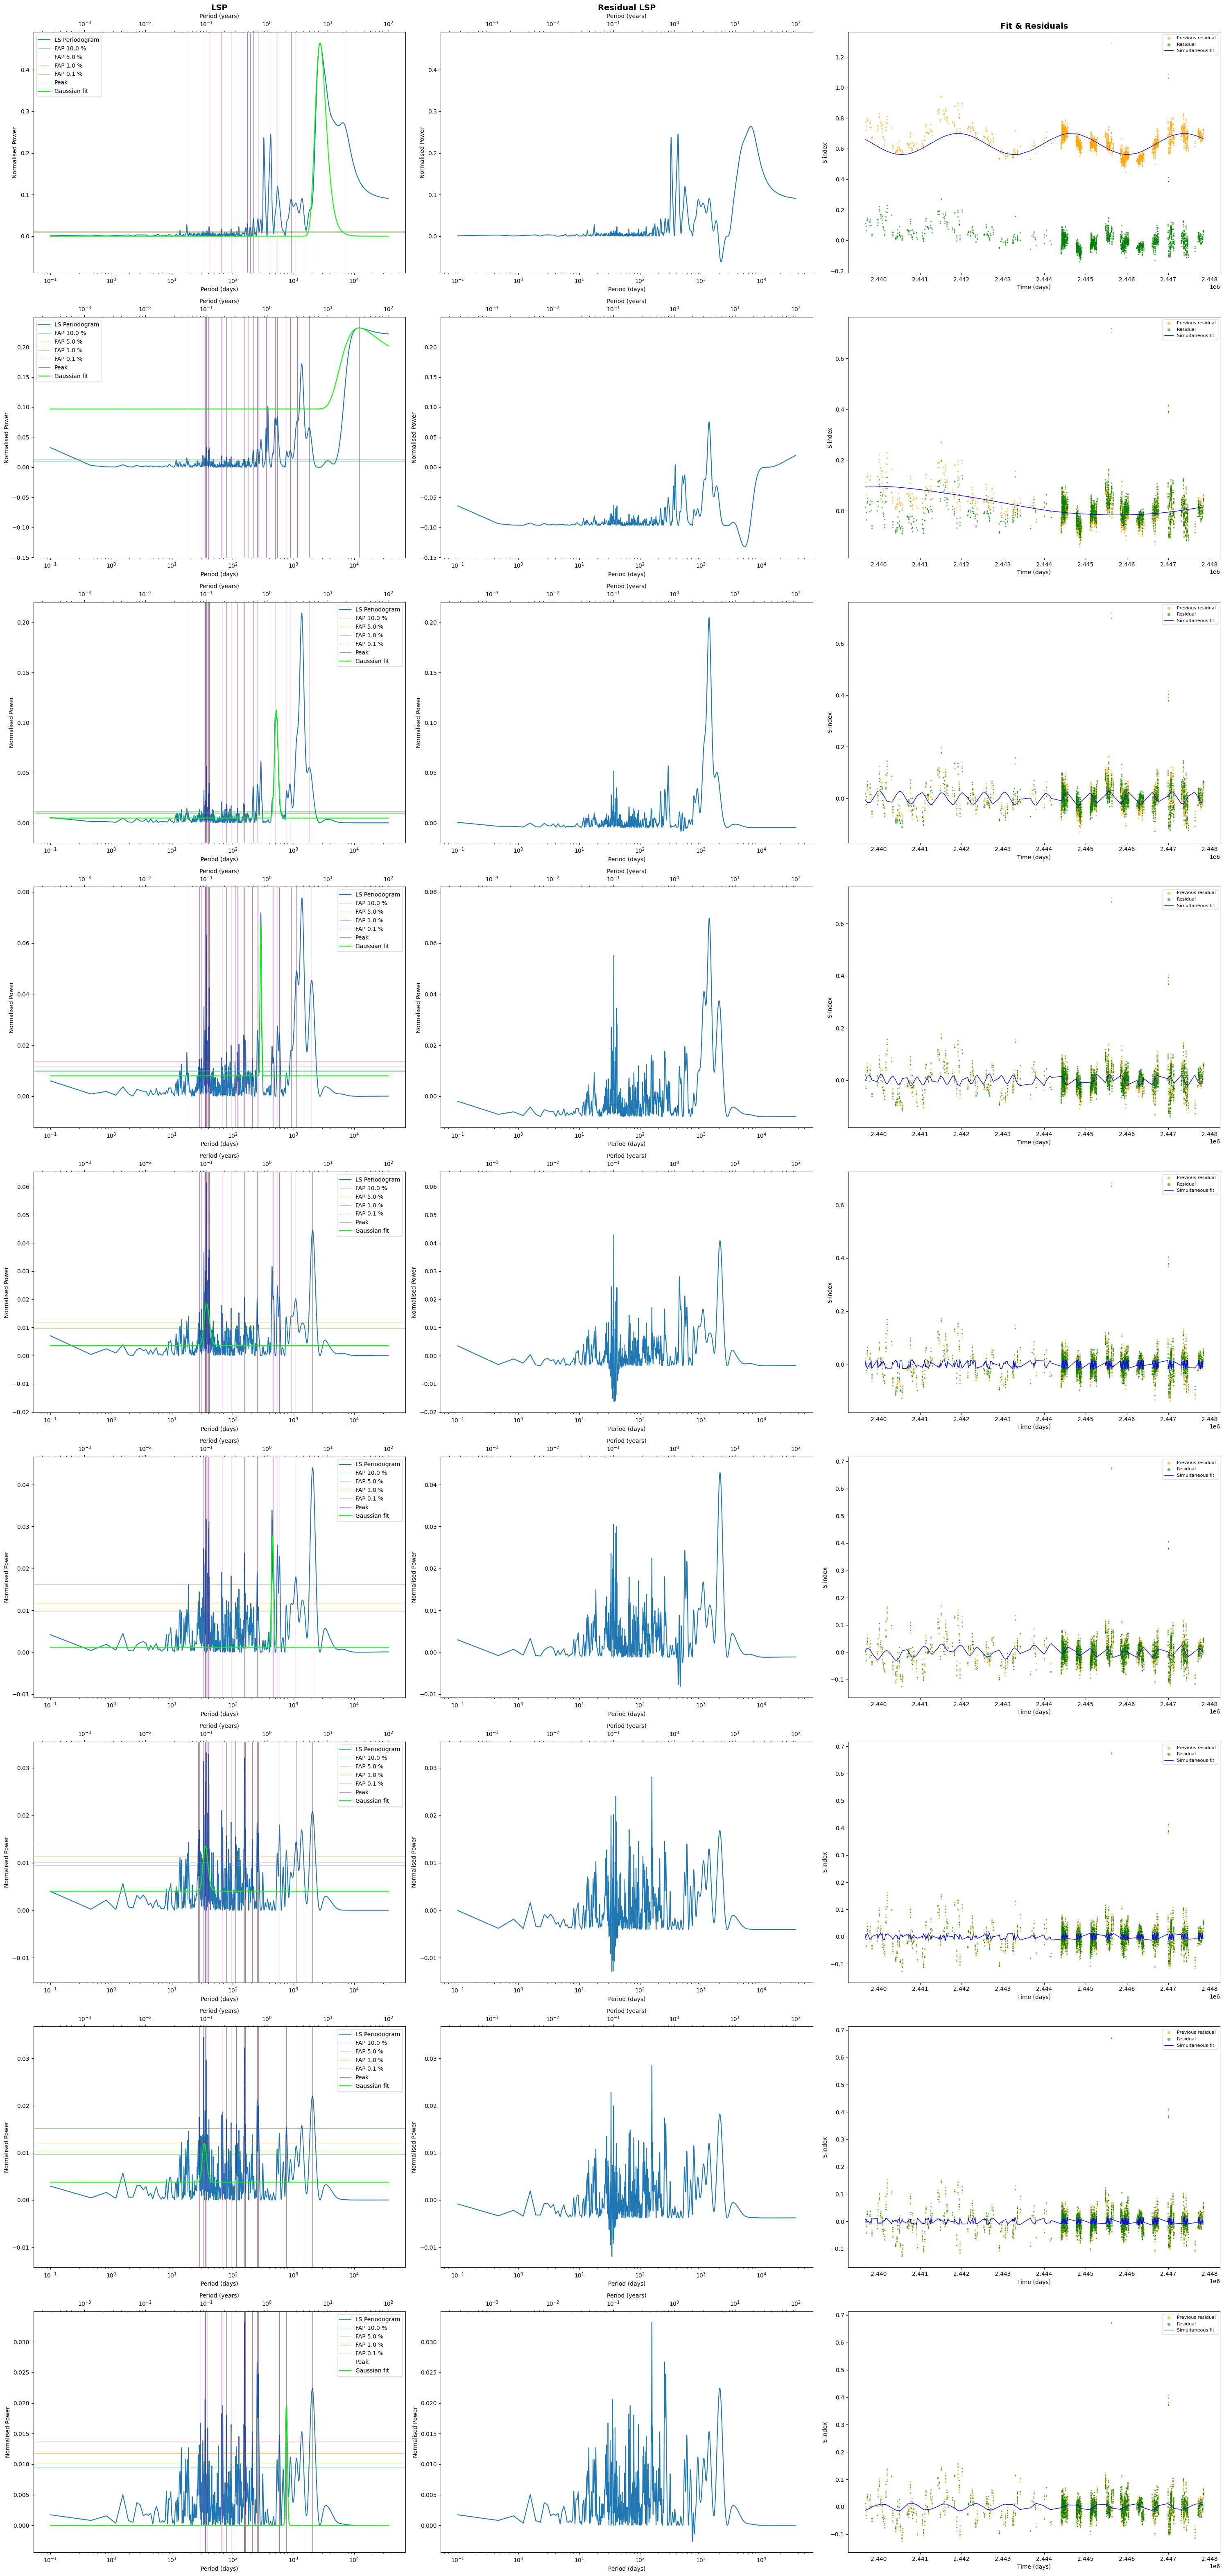

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 |  0.46  |   23570.79   |
| 12043.36 | 33.00 |  0.23  | 117241745.13 |
|  505.26  |  1.38 |  0.11  |    18.65     |
|  290.64  |  0.80 |  0.07  |    10.01     |
|  36.97   |  0.10 |  0.06  |     9.87     |
|  443.94  |  1.22 |  0.03  |     7.53     |
|  39.89   |  0.11 |  0.03  |     6.19     |
|  33.32   |  0.09 |  0.03  |     7.37     |
|  762.59  |  2.09 |  0.02  |    13.95     |
+----------+-------+--------+--------------+


In [ ]:
peaks_HD201091, heights_HD201091 = fit_peaks(train_HD201091)

# THESE ALL MATCH THE LITERATURE!!!!!
